<a href="https://www.kaggle.com/code/sahasdubey25/notebook4844a73414?scriptVersionId=256565477" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [112]:
import torch 
import seaborn as sns
import torch.nn as nn
import numpy as np 
import pandas as pd 
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
import os


import warnings
warnings.filterwarnings('ignore')

In [113]:
file_count = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    file_count += len(filenames)

print(f'Total files in /kaggle/input: {file_count}')

Total files in /kaggle/input: 10287


In [114]:
os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training')

['pituitary', 'notumor', 'meningioma', 'glioma']

In [115]:
torch.manual_seed(42)

In [116]:
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

In [117]:
train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  #normalizing X-ray images just led to more randomness in the final accuracy
])

test_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  
])

In [118]:
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

In [119]:
print(test_data.classes)
print(train_data.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']
['glioma', 'meningioma', 'notumor', 'pituitary']


In [120]:
class_names = train_data.classes
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [121]:
train_loader = DataLoader(train_data, batch_size = 32, shuffle = True, drop_last = True)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

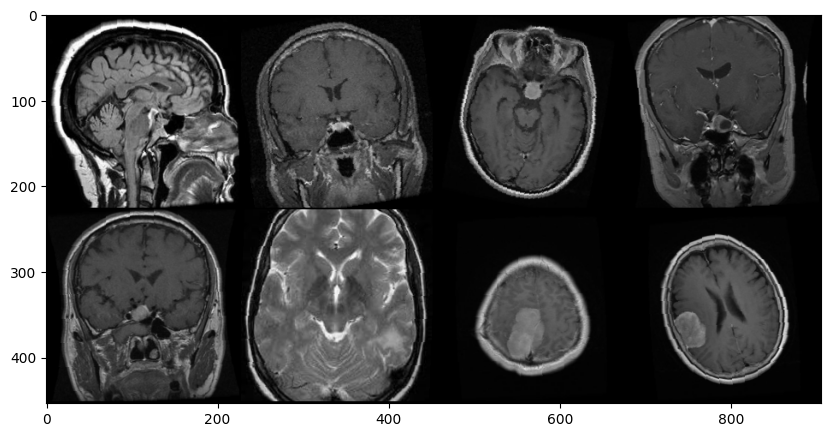

In [122]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
plt.figure(figsize=(10, 8))
plt.imshow(make_grid(images[:8], nrow=4).permute(1, 2, 0))
plt.show()

# Model Overview

This Convolutional Neural Network is built for image classification. It has three convolutional layers (each with ReLU activation and max pooling for feature extraction and dimensionality reduction) followed by three fully connected layers. The network ends with a log softmax activation to output probabilities for four classes.

In [123]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)    
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)   
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  
        
        self.fc1 = nn.Linear(128*28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 4)  

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)     

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)     

        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)     

        X = X.view(-1, 128*28*28)    
        
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)               

        return F.log_softmax(X, dim=1)

In [124]:
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

In [125]:
for param in model.parameters():
    print(param.numel())

2400
32
18432
64
73728
128
25690112
256
32768
128
512
4


In [126]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvolutionalNetwork().to(device)

In [127]:
criterion = nn.CrossEntropyLoss()  # For multi-class classification (no need for log_softmax during training if using this)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training and Evaluation
This following code trains the model over multiple epochs, printing training progress every 25 batches. It tracks and stores training and test losses and accuracies. Finally, it reports the total training time.

In [128]:
import time

epochs = 11
max_trn_batch = 800
max_tst_batch = 300
train_losses = []
test_losses = []
train_correct = []
test_correct = []
start_time = time.time()
total_samples = len(train_loader.dataset)

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    running_train_loss = 0.0
    running_test_loss = 0.0
    test_batches = 0
    train_batches = 0

    
    model.train()
    for b, (X_train, y_train) in enumerate(train_loader):
        if b == max_trn_batch:
            break
        
        
        X_train, y_train = X_train.to(device), y_train.to(device)

        
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        running_train_loss += loss.item()
        train_batches += 1
        
        predicted = torch.max(y_pred, 1)[1]
        trn_corr += (predicted == y_train).sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if b % 200 == 0:
            samples_seen = (b+1) * X_train.size(0)
            percentage = (samples_seen / total_samples) * 100
            accuracy = trn_corr * 100 / samples_seen
            print(f'epoch: {i+1 :2}  batch: {b:4} [{ percentage:6.2f}%]  loss: {loss.item():10.8f}  accuracy: {accuracy:7.2f}%')

    train_losses.append(running_train_loss / train_batches)
    train_correct.append(trn_corr)


    
    model.eval()
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break
                
            X_test, y_test = X_test.to(device), y_test.to(device)
            
            y_val = model(X_test)
            loss = criterion(y_val, y_test)
            running_test_loss += loss.item()
            test_batches += 1
            
            predicted = torch.max(y_val, 1)[1]
            tst_corr += (predicted == y_test).sum().item()
            
    test_losses.append(running_test_loss / test_batches)
    test_correct.append(tst_corr)

print(f'\n time taken to train: {(time.time() - start_time)/60:.0f} minutes')

epoch:  1  batch:    0 [  0.56%]  loss: 1.38310635  accuracy:   28.12%
epoch:  2  batch:    0 [  0.56%]  loss: 0.45635983  accuracy:   78.12%
epoch:  3  batch:    0 [  0.56%]  loss: 0.50918508  accuracy:   78.12%
epoch:  4  batch:    0 [  0.56%]  loss: 0.27987826  accuracy:   90.62%
epoch:  5  batch:    0 [  0.56%]  loss: 0.11691231  accuracy:   93.75%
epoch:  6  batch:    0 [  0.56%]  loss: 0.41457263  accuracy:   81.25%
epoch:  7  batch:    0 [  0.56%]  loss: 0.13256893  accuracy:   93.75%
epoch:  8  batch:    0 [  0.56%]  loss: 0.15923390  accuracy:   93.75%
epoch:  9  batch:    0 [  0.56%]  loss: 0.10376544  accuracy:   96.88%
epoch: 10  batch:    0 [  0.56%]  loss: 0.02972338  accuracy:  100.00%
epoch: 11  batch:    0 [  0.56%]  loss: 0.02807198  accuracy:  100.00%

 time taken to train: 6 minutes


# Next, lets evaluate the model performance

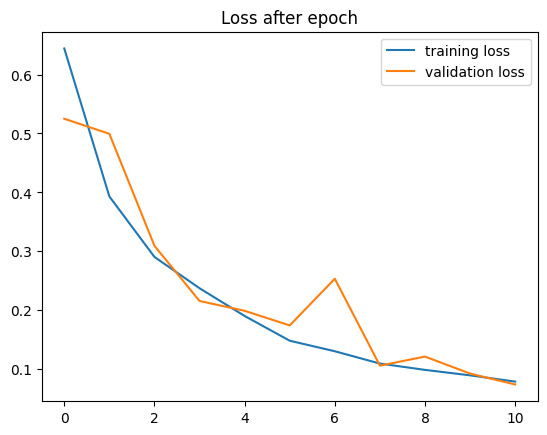

In [129]:
plt.plot(range(epochs),train_losses, label = 'training loss')
plt.plot(range(epochs), test_losses, label= 'validation loss')
plt.title('Loss after epoch')
plt.legend();
plt.show()

## Interpretation:

Both training and validation loss decrease steadily over the epochs. This shows the model is learning and generalizing well. The validation loss varies a bit but mostly follows the trend of the training loss. This indicates that there is no significant overfitting and that performance is stable.

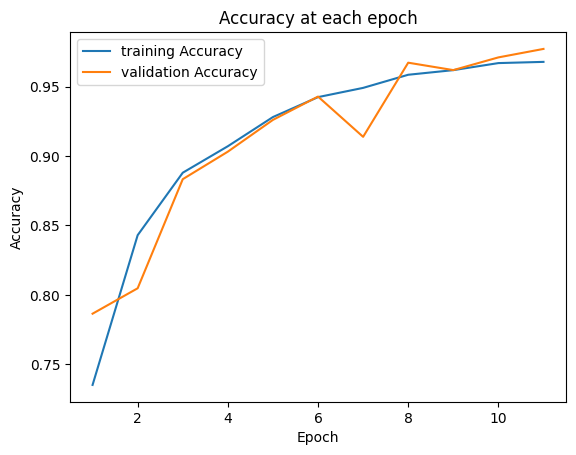

In [130]:
epochs = len(train_correct)


train_acc = [c / len(train_data) for c in train_correct]
val_acc = [c / len(test_data) for c in test_correct]

plt.plot(range(1, epochs + 1), train_acc, label='training Accuracy')
plt.plot(range(1, epochs + 1), val_acc, label='validation Accuracy')
plt.title('Accuracy at each epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Interpretation:

Training and validation accuracy steadily rise over epochs, surpassing 95%. The close relationship between the two curves indicates that the model generalizes well, with little overfitting and strong performance on new data.

In [131]:
def calculate_accuracy(model, data_loader, device):
    model.eval()  
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)  
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy
                                                                                                  
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 97.71%


In [132]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

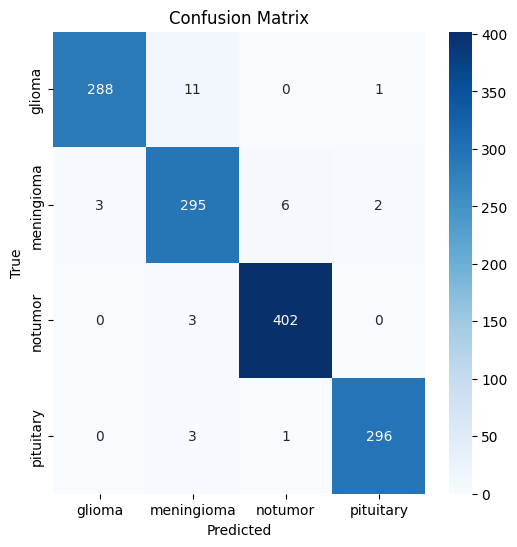

In [133]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Interpretation:  

The confusion matrix demonstrates strong performance. Most predictions land on the diagonal for all classes. Misclassifications are minimal. This means the model correctly identifies glioma, meningioma, notumor, and pituitary tumor types.

___

# Additional Evaluation:


Here, the model is also tested on an entirely different dataset to validate its robustness. This approach demonstrates the model’s strong generalization ability and reliability across diverse data sources, which is crucial for real-world medical applications.


In [134]:
new_data_dir = '/kaggle/input/brain-tumor-classification-mri/Training'
new_dataset = datasets.ImageFolder(root=new_data_dir, transform=test_transforms)
new_loader = torch.utils.data.DataLoader(new_dataset, batch_size=32, shuffle=True)

In [135]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in new_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print("Accuracy on the new dataset:", 100 * correct / total)

Accuracy on the new dataset: 98.50174216027875


# Next, lets try comparing it to DenseNet121 using transfer learning 

DenseNet121 is a 121-layer convolutional network that connects each layer to every other layer, improving feature reuse and gradient flow. 
It is highly reliable and widely used for medical imaging tasks due to its strong performance and efficiency.

In [136]:
densenet121 = models.densenet121(pretrained = True)

for param in densenet121.parameters():
    param.requires_grad = False

In [137]:
densenet121.classifier = nn.Linear(densenet121.classifier.in_features, 4)

In [138]:
densenet121 = densenet121.to(device)
torch.manual_seed(101)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(densenet121.classifier.parameters(), lr=0.001, weight_decay=1e-4)

In [139]:
epochs = 10
for epoch in range(epochs):
    densenet121.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = densenet121(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f'Epoch: [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc*100:.2f}%')


Epoch: [1/10], Loss: 0.6907, Accuracy: 76.40%
Epoch: [2/10], Loss: 0.4412, Accuracy: 84.80%
Epoch: [3/10], Loss: 0.3824, Accuracy: 86.62%
Epoch: [4/10], Loss: 0.3573, Accuracy: 86.87%
Epoch: [5/10], Loss: 0.3311, Accuracy: 88.06%
Epoch: [6/10], Loss: 0.3280, Accuracy: 87.90%
Epoch: [7/10], Loss: 0.3011, Accuracy: 89.04%
Epoch: [8/10], Loss: 0.2956, Accuracy: 89.22%
Epoch: [9/10], Loss: 0.2876, Accuracy: 89.69%
Epoch: [10/10], Loss: 0.2806, Accuracy: 89.82%


In [140]:
densenet121.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = densenet121(images)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

final_test_acc = test_correct / test_total
print(f'Final Test Accuracy: {final_test_acc*100:.2f}%')


Final Test Accuracy: 86.73%


## Interpretation

Here, the results indicate that my model performs slightly better than DenseNet121, suggesting its promising potential for this specific application.
___
___